<a href="https://colab.research.google.com/github/mmadhumitha-22/Birru-Madhumitha/blob/main/predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== MODEL ACCURACY ==========
R2 Score: 0.25

========== FUTURE SALES PREDICTIONS ==========
Future Month 1: $69957.54
Future Month 2: $70859.54
Future Month 3: $71761.55
Future Month 4: $72663.56
Future Month 5: $73565.57
Future Month 6: $74467.57


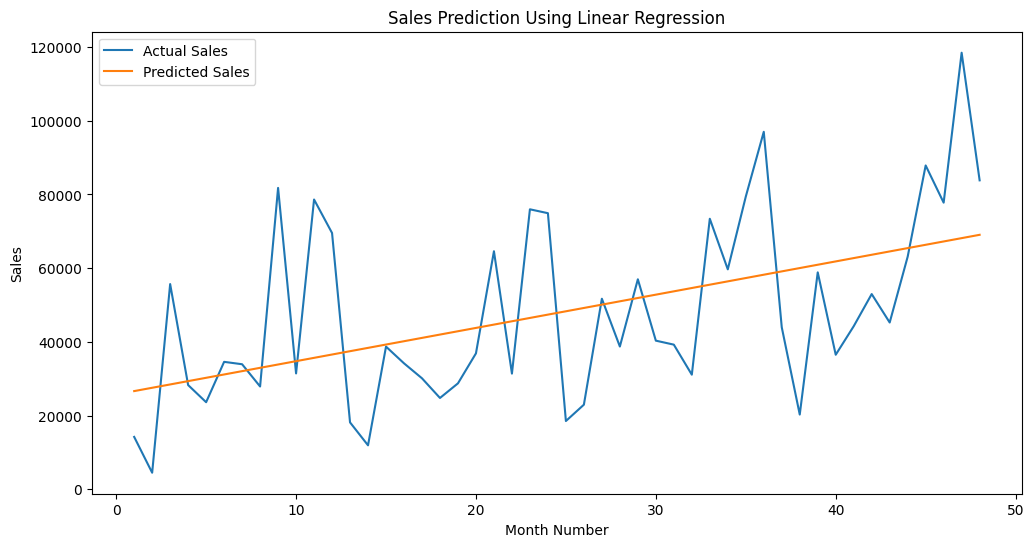


Predictive Analytics Project Completed Successfully!
Output file saved as: sales_predictions.csv


In [ ]:
# ==========================================
# PREDICTIVE ANALYTICS USING HISTORICAL DATA
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(
    '/content/Sample - Superstore.csv',
    encoding='latin1'
)

# ==========================================
# DATA PREPROCESSING
# ==========================================

# Convert Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort data by date
df = df.sort_values('Order Date')

# Create Monthly Sales Data
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum().reset_index()

# Convert period to timestamp
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
monthly_sales['Order Date'] = pd.to_datetime(monthly_sales['Order Date'])

# ==========================================
# CREATE TIME INDEX
# ==========================================

monthly_sales['Month_Number'] = range(1, len(monthly_sales) + 1)

# Features and Target
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

# ==========================================
# TRAIN LINEAR REGRESSION MODEL
# ==========================================

model = LinearRegression()

model.fit(X, y)

# ==========================================
# PREDICT SALES
# ==========================================

monthly_sales['Predicted_Sales'] = model.predict(X)

# ==========================================
# CALCULATE ACCURACY
# ==========================================

accuracy = r2_score(y, monthly_sales['Predicted_Sales'])

print("========== MODEL ACCURACY ==========")
print(f"R2 Score: {accuracy:.2f}")

# ==========================================
# FUTURE SALES PREDICTION
# ==========================================

future_months = pd.DataFrame({
    'Month_Number': range(len(monthly_sales)+1,
                          len(monthly_sales)+7)
})

future_predictions = model.predict(future_months)

print("\n========== FUTURE SALES PREDICTIONS ==========")

for i, prediction in enumerate(future_predictions, start=1):
    print(f"Future Month {i}: ${prediction:.2f}")

# ==========================================
# VISUALIZATION
# ==========================================

plt.figure(figsize=(12,6))

# Actual Sales
plt.plot(
    monthly_sales['Month_Number'],
    monthly_sales['Sales'],
    label='Actual Sales'
)

# Predicted Sales
plt.plot(
    monthly_sales['Month_Number'],
    monthly_sales['Predicted_Sales'],
    label='Predicted Sales'
)

plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('Sales Prediction Using Linear Regression')

plt.legend()

plt.show()

# ==========================================
# SAVE OUTPUT
# ==========================================

monthly_sales.to_csv(
    'sales_predictions.csv',
    index=False
)

print("\nPredictive Analytics Project Completed Successfully!")
print("Output file saved as: sales_predictions.csv")

In [ ]:
print(f"R2 Score: {accuracy:.2f}")

R2 Score: 0.25


In [ ]:
print(f"Future Month {i}: ${prediction:.2f}")

Future Month 6: $74467.57
